In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from pathlib import Path

In [ ]:
# Pathes

root = Path(r"D:\Python\Data_Analisys\Tennis Project\tennis_data")
processed = Path(r"D:\Python\Data_Analisys\Tennis Project\processed_data")
processed.mkdir(exist_ok=True)


# Dictionary For Saving Data Frames

data = {

    "away_team": [],
    "away_team_score": [],
    "event": [],
    "home_team": [],
    "home_team_score": [],
    "round": [],
    "season": [],
    "time": [],
    "tournament": [],
    "venue": [],

    "odds": [],
    "pbp": [],
    "statistics": [],
    "power": [],
    "votes": []
}

# All Zip Files

zip_files = sorted(root.glob("*.zip"))
print(f"\nFound {len(zip_files)} zip files.\n")


# Reading All Zip Files

for zip_path in zip_files:
    print(f"Reading : {zip_path.name}")
    with zipfile.ZipFile(zip_path,"r") as z:
        for file in z.namelist():
            if not file.endswith(".parquet"):
                continue

            with z.open(file) as f:
                df = pd.read_parquet(f)
                filename = Path(file).stem
                if filename.startswith("away_team_score"):
                    data["away_team_score"].append(df)

                elif filename.startswith("away_team"):
                    data["away_team"].append(df)

                elif filename.startswith("home_team_score"):
                    data["home_team_score"].append(df)

                elif filename.startswith("home_team"):
                    data["home_team"].append(df)

                elif filename.startswith("event"):
                    data["event"].append(df)

                elif filename.startswith("round"):
                    data["round"].append(df)

                elif filename.startswith("season"):
                    data["season"].append(df)

                elif filename.startswith("time"):
                    data["time"].append(df)

                elif filename.startswith("tournament"):
                    data["tournament"].append(df)

                elif filename.startswith("venue"):
                    data["venue"].append(df)

                elif filename.startswith("odds"):
                    data["odds"].append(df)

                elif filename.startswith("pbp"):
                    data["pbp"].append(df)

                elif filename.startswith("statistics"):
                    data["statistics"].append(df)

                elif filename.startswith("power"):
                    data["power"].append(df)

                elif filename.startswith("votes"):
                    data["votes"].append(df)
print("\nFinished reading ZIP files.\n")



# Creating Data Frames
# Show DataFrame Rows and Columns

dfs = {}
for name, frames in data.items():
    if len(frames) > 0:
        dfs[name] = pd.concat(frames, ignore_index=True)
        print(f"{name:20s} --> {dfs[name].shape}")

# Saving CSVs

for name, df in dfs.items():
    output = processed / f"{name}.csv"
    df.to_csv(output,index=False)

print("\nAll CSV files saved successfully.\n")

In [2]:
processed = Path(r"E:\MidTerm Project\coaprating zone\processed_data")

away_team_df = pd.read_csv(processed / "away_team.csv")
away_team_score_df = pd.read_csv(processed / "away_team_score.csv")
event_df = pd.read_csv(processed / "event.csv")
home_team_df = pd.read_csv(processed / "home_team.csv")
home_team_score_df = pd.read_csv(processed / "home_team_score.csv")
round_df = pd.read_csv(processed / "round.csv")
season_df = pd.read_csv(processed / "season.csv")
time_df = pd.read_csv(processed / "time.csv")
tournament_df = pd.read_csv(processed / "tournament.csv")
venue_df = pd.read_csv(processed / "venue.csv")
odds_df = pd.read_csv(processed / "odds.csv")
pbp_df = pd.read_csv(processed / "pbp.csv")
statistics_df = pd.read_csv(processed / "statistics.csv")
power_df = pd.read_csv(processed / "power.csv")
votes_df = pd.read_csv(processed / "votes.csv")

In [3]:
#Be Ready For Merging
home_team_score_df = home_team_score_df.drop_duplicates(subset='match_id', keep='first')
home_team_df = home_team_df.drop_duplicates(subset='match_id', keep='first')
away_team_score_df = away_team_score_df.drop_duplicates(subset='match_id', keep='first')
away_team_df = away_team_df.drop_duplicates(subset='match_id', keep='first')
event_df = event_df.drop_duplicates(subset='match_id', keep='first')

<br><br>

## 1. How many tennis players are included in the dataset?

In [4]:
concated_away_home_teams = pd.concat([away_team_df, home_team_df], axis='rows').reset_index(drop=True)

In [5]:
players = concated_away_home_teams['full_name'].drop_duplicates().to_frame()
players

,full_name
0,"Auger-Aliassime, Felix"
1,Flavio Cobolli
2,"Martinez, Pedro"
3,"Muller, Alexandre"
4,"Mayot, Harold"
...,...
23685,"Davis, Lauren"
23695,"Melichar-Martinez, Nicole"
23822,"Urribarrens Ramirez, Iker"
24031,"Gadient, Nicole"


In [6]:
players.count().to_frame(name = 'Players Numbers')

,Players Numbers
full_name,2648


#### We have **2651** tennis players in the dataset .

<br><br>

## 2. What is the average height of the players?

In [7]:
indexes = concated_away_home_teams['name'].drop_duplicates().index
height_players = concated_away_home_teams['height'].loc[indexes].to_frame()
height_players

,height
0,1.93
1,1.83
2,1.85
3,1.83
4,1.78
...,...
23685,1.57
23695,1.81
23822,NaN
24031,NaN


In [8]:
fill_value = height_players.dropna().mean().round(2)
height_players = height_players.fillna(fill_value)
height_players

,height
0,1.93
1,1.83
2,1.85
3,1.83
4,1.78
...,...
23685,1.57
23695,1.81
23822,1.82
24031,1.82


In [9]:
height_players.mean().round(2).to_frame(name='Avrage Height Players')

,Avrage Height Players
height,1.82


#### Avrage height players in the dataset are **1.82 cm** .

<br><br>

## 3. Which player has the highest number of wins?

In [10]:
home = home_team_df[["match_id", "player_id", "full_name"]].rename(columns={"player_id": "home_player_id","full_name": "home_player"})
away = away_team_df[["match_id", "player_id", "full_name"]].rename(columns={"player_id": "away_player_id","full_name": "away_player"})

In [11]:
matches = event_df.merge(home, on="match_id", how="left")
matches = matches.merge(away, on="match_id", how="left")
matches.head()

,match_id,first_to_serve,home_team_seed,away_team_seed,custom_id,winner_code,default_period_count,start_datetime,match_slug,final_result_only,home_player_id,home_player,away_player_id,away_player
0,11974053,NaN,NaN,NaN,NNfsQTf,1.0,3,1706878800,switzerland-netherlands,False,NaN,NaN,NaN,NaN
1,11974066,NaN,NaN,NaN,hTfsrpg,2.0,3,1706871600,ukraine-usa,False,NaN,NaN,NaN,NaN
2,11998445,1.0,NaN,3,nPBbsdgpc,2.0,3,1706810400,cazaux-auger-aliassime,False,287803.0,"Cazaux, Arthur",192013.0,"Auger-Aliassime, Felix"
3,11998446,2.0,NaN,NaN,PfAsFyjc,2.0,3,1706800800,cobolli-lestienne,False,62790.0,"Lestienne, Constant",273680.0,Flavio Cobolli
4,11998447,1.0,4,NaN,FQAsyUF,1.0,3,1706794200,martinez-coric,False,64580.0,"Ćorić, Borna",77223.0,"Martinez, Pedro"


In [12]:
matches["winner_id"] = np.where(matches["winner_code"] == 1, matches["home_player_id"], matches["away_player_id"])
matches["winner_name"] = np.where(matches["winner_code"] == 1, matches["home_player"], matches["away_player"])

In [13]:
wins = (matches.groupby(["winner_id", "winner_name"])
                .size()
                .reset_index(name="wins")
                .sort_values(by="wins", ascending=False))

wins = wins[['winner_name', 'wins','winner_id']].head(6)
wins

,winner_name,wins,winner_id
195,"Popko, Dmitry",31,50901.0
1282,"Chidekh, Clement",24,231620.0
1926,"Faria, Jaime",22,341818.0
1265,"Jianu, Filip Cristian",21,230049.0
1339,"Ovcharenko, Oleksandr",21,238867.0
1024,"Gengel, Marek",21,202572.0


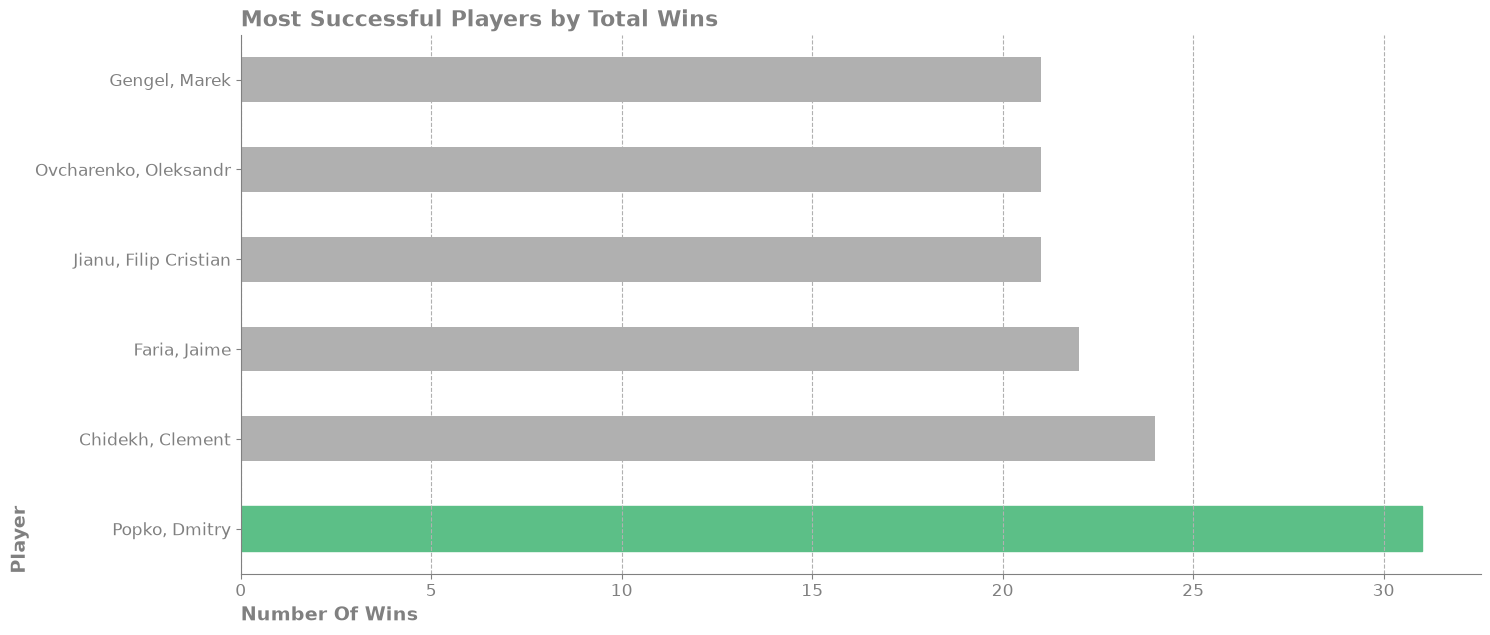

In [ ]:
fig , ax = plt.subplots(figsize=(16,7))
wins.plot(kind='barh', ax=ax, x='winner_name', y='wins', color='#B0B0B0', legend=False)
ax.patches[0].set_color("#5CBF87")

ax.spines[["right", "top"]].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.set_title('Most Successful Players by Total Wins', loc='left',weight='bold',color='gray',fontsize=16)
ax.set_xlabel('Number Of Wins',loc="left", weight="bold", color="gray", fontsize=14 )
ax.set_ylabel('Player',loc="bottom", weight="bold", color="gray", fontsize=14 )

ax.grid(axis='x', linestyle='dashed')

#fig.savefig("3_Most Successful Players by Total Wins.png", dpi=300, bbox_inches="tight")
plt.show()

<br><br>

## 4. What is the longest match recorded in terms of duration?

In [15]:
time = time_df[['match_id','period_1','period_2','period_3','period_4','period_5']].fillna(0).drop_duplicates()
time = time[((time["period_1"] > 600) & (time["period_1"] < 10800)) &
            ((time["period_2"] > 600) & (time["period_2"] < 10800)) &
            ((time["period_3"] == 0) | ( (time["period_3"] > 600) & (time["period_3"] < 10800) ) ) &
            ((time["period_4"] == 0) | ( (time["period_4"] > 600) & (time["period_4"] < 10800) ) ) &
            ((time["period_5"] == 0) | ( (time["period_5"] > 600) & (time["period_5"] < 10800) ) ) ]

In [16]:
time['match_duration'] = time['period_1'] + time['period_2'] + time['period_3'] + time['period_4'] + time['period_5']
longest_match = time.sort_values(by='match_duration', ascending=False).head(1)
longest_match

,match_id,period_1,period_2,period_3,period_4,period_5,match_duration
20223,12136283,4884.0,4418.0,10569.0,0.0,0.0,19871.0


In [17]:
longest_match['match_id']

20223    12136283
Name: match_id, dtype: int64

In [18]:
all_matches = pd.merge(home_team_df, away_team_df, on='match_id', suffixes=['_home','_away'])

In [19]:
all_matches[all_matches["match_id"] == 12136283][['full_name_home','full_name_away']]

,full_name_home,full_name_away
5937,"Milev, Yanaki","La Vela, Giuseppe"


#### The battle between *Yanaki Milev vs Giuseppe La Vela* was the longest duration.

<br><br>

## 5. How many sets are typically played in a tennis match?

In [20]:
score = pd.merge(home_team_score_df, away_team_score_df, on='match_id', suffixes=['_home','_away'])

In [21]:
set_scores = score.filter(regex='current|match')
set_scores['all_sets_played'] = set_scores['current_score_home'] + set_scores['current_score_away']

In [22]:
bad_matches = score[
    ((score['current_score_home'] == 0) & (score['current_score_away'] == 0)) |
    ((score['current_score_home'] == 1) & (score['current_score_away'] == 1)) |
    ((score['current_score_home'] == 2) & (score['current_score_away'] == 2)) |
    ((score['current_score_home'] == 1) & (score['current_score_away'] == 0)) |
    ((score['current_score_home'] == 0) & (score['current_score_away'] == 1)) ]

set_scores = set_scores[~set_scores['match_id'].isin(bad_matches['match_id'])]

In [23]:
def select_winner(x):
    if x['current_score_home'] > x['current_score_away']:
       return 'home'
    elif x['current_score_home'] < x['current_score_away']:
        return 'away'
    else:
        return 'draw'

set_scores['winner'] = set_scores.apply(select_winner, axis=1)

In [24]:
home_outlier_currentscore = set_scores[set_scores['current_score_home'] == 4.0].index
away_outlier_currentscore = set_scores[set_scores['current_score_away'] == 4.0].index
set_scores = set_scores.drop(home_outlier_currentscore, axis='rows')
set_scores = set_scores.drop(away_outlier_currentscore, axis='rows')
set_scores

,match_id,current_score_home,current_score_away,all_sets_played,winner
0,11974053,3.0,2.0,5.0,home
2,11998445,1.0,2.0,3.0,away
3,11998446,0.0,2.0,2.0,away
4,11998447,2.0,0.0,2.0,home
5,11998448,2.0,0.0,2.0,home
...,...,...,...,...,...
16868,12213482,2.0,0.0,2.0,home
16869,12213483,2.0,0.0,2.0,home
16870,12213484,2.0,0.0,2.0,home
16871,12213486,2.0,0.0,2.0,home


In [25]:
two_on_three_matches_filter = score[
    ((score['current_score_home'] == 0) & (score['current_score_away'] == 2)) |
    ((score['current_score_home'] == 2) & (score['current_score_away'] == 0)) |
    ((score['current_score_home'] == 2) & (score['current_score_away'] == 1)) |
    ((score['current_score_home'] == 1) & (score['current_score_away'] == 2)) ]

three_on_five_matches_filter = score[
    ((score['current_score_home'] == 0) & (score['current_score_away'] == 3)) |
    ((score['current_score_home'] == 3) & (score['current_score_away'] == 0)) |
    ((score['current_score_home'] == 1) & (score['current_score_away'] == 3)) |
    ((score['current_score_home'] == 3) & (score['current_score_away'] == 1)) |
    ((score['current_score_home'] == 2) & (score['current_score_away'] == 3)) |
    ((score['current_score_home'] == 3) & (score['current_score_away'] == 2))]

In [26]:
two_on_three_matches = set_scores[set_scores['match_id'].isin(two_on_three_matches_filter['match_id'])]
three_on_five_matches = set_scores[set_scores['match_id'].isin(three_on_five_matches_filter['match_id'])]

In [27]:
two_on_three_matches['all_sets_played'].aggregate(AVG='mean').round(2).to_frame()

,all_sets_played
AVG,2.3


#### In 2 on 3 games usually playing about 2 sets.

In [28]:
three_on_five_matches['all_sets_played'].aggregate(AVG='mean').round(2).to_frame()

,all_sets_played
AVG,3.73


#### But in 3 on 5 games typically game will play about 4 sets.

<br><br>

## 6. Which country has produced the most successful tennis players?

In [29]:
finals_match_id = round_df[round_df['name'] == 'Final']['match_id']

In [30]:
final_matches_set_scores = set_scores[set_scores['match_id'].isin(finals_match_id)]
home_team_champions_match_id = final_matches_set_scores[final_matches_set_scores['winner'] == 'home']['match_id']
away_team_champions_match_id = final_matches_set_scores[final_matches_set_scores['winner'] == 'away']['match_id']

In [31]:
opponents = all_matches.filter(regex='match|full_name')

In [32]:
home_teams_champions_names = opponents[opponents['match_id'].isin(home_team_champions_match_id)]['full_name_home']
away_teams_champions_names = opponents[opponents['match_id'].isin(away_team_champions_match_id)]['full_name_home']

In [33]:
home_teams_champions_nations = all_matches[all_matches['full_name_home'].isin(home_teams_champions_names)]['country_home']
away_teams_champions_nations = all_matches[all_matches['full_name_home'].isin(away_teams_champions_names)]['country_home']
all_champions_countries = pd.concat([home_teams_champions_nations, away_teams_champions_nations], axis='rows')

In [34]:
all_champions_countries = all_champions_countries.value_counts().to_frame(name='Trophies_Number').rename_axis('country').head()
all_champions_countries

,Trophies_Number
country,
France,164
USA,107
Australia,101
Russia,86
Argentina,78


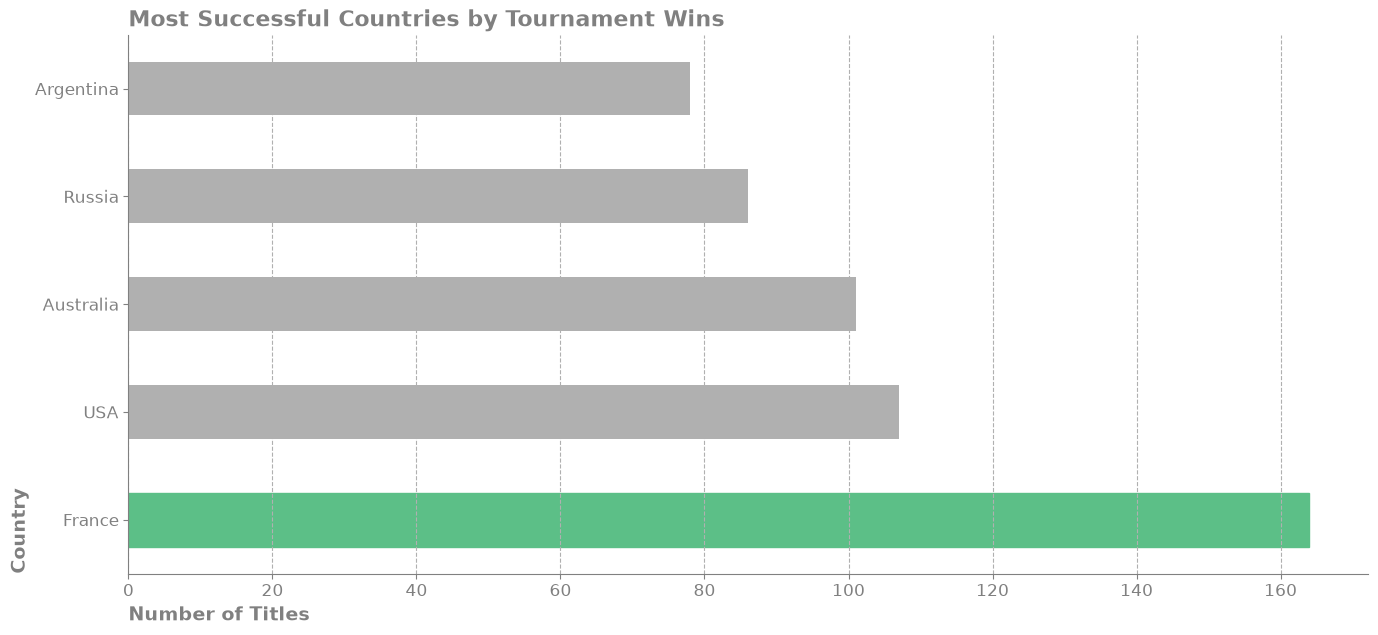

In [ ]:
fig , ax = plt.subplots(figsize=(16,7))
all_champions_countries.plot(kind='barh', ax=ax, color='#B0B0B0', legend=False)
ax.patches[0].set_color("#5CBF87")

ax.spines[["right", "top"]].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.set_title('Most Successful Countries by Tournament Wins', loc='left',weight='bold',color='gray',fontsize=16)
ax.set_xlabel('Number of Titles',loc="left", weight="bold", color="gray", fontsize=14 )
ax.set_ylabel('Country',loc="bottom", weight="bold", color="gray", fontsize=14 )

ax.grid(axis='x', linestyle='dashed')

#fig.savefig("6_Most Successful Countries by Tournament Wins.png", dpi=300, bbox_inches="tight")
plt.show()

<br><br>

## 7. What is the average number of aces per match?

In [36]:
all_aces_per_match =( statistics_df[(statistics_df['period']=='ALL') & (statistics_df['statistic_name']=='aces')]
                     .filter(regex='match_id|statistic_name|home_value|away_value'))
all_aces_per_match['all_value'] = all_aces_per_match['home_value'] + all_aces_per_match['away_value']
all_aces_per_match

,match_id,statistic_name,home_value,away_value,all_value
0,11998445,aces,12,6,18
71,11998446,aces,6,3,9
125,11998447,aces,8,4,12
178,11998448,aces,4,0,4
232,11998449,aces,6,4,10
...,...,...,...,...,...
1357965,12213482,aces,0,1,1
1358019,12213483,aces,0,0,0
1358073,12213484,aces,1,0,1
1358127,12213486,aces,0,1,1


In [37]:
avg = all_aces_per_match['all_value'].mean()
avg_ace_per_match = pd.DataFrame([avg], columns=['avg_ace_per_match']).round(2)
avg_ace_per_match

,avg_ace_per_match
0,5.35


#### Normally every game has about 5 aces 

<br><br>

## 8. Is there a difference in the number of double faults based on gender?

In [38]:
matches_based_on_gender = all_matches[['match_id','gender_home','gender_away']]

In [39]:
matches_based_on_gender.query('gender_home != gender_away')

,match_id,gender_home,gender_away
1167,12048797,F,NaN
1244,12046921,NaN,M
1800,12061822,NaN,M
2430,12066194,F,NaN
2440,12069886,F,NaN
2596,12072439,NaN,F
3097,12083172,NaN,M
3266,12086201,M,NaN
4402,12105398,NaN,M
4658,12106307,NaN,M


In [40]:
fill_gender_away = matches_based_on_gender['gender_home'].dropna()
matches_based_on_gender['gender_away'] = matches_based_on_gender['gender_away'].fillna(fill_gender_away)
fill_gender_home = matches_based_on_gender['gender_away'].dropna()
matches_based_on_gender['gender_home'] = matches_based_on_gender['gender_home'].fillna(fill_gender_home)

In [41]:
all_double_faults = statistics_df[ (statistics_df['statistic_name'] == 'double_faults') & (statistics_df['period'] == 'ALL')]
all_double_faults['all_doublt_faults'] = all_double_faults['home_value'] + all_double_faults['away_value'] 
all_double_faults = all_double_faults[['match_id', 'all_doublt_faults']]
all_double_faults

,match_id,all_doublt_faults
1,11998445,9
72,11998446,3
126,11998447,5
179,11998448,4
233,11998449,5
...,...,...
1357966,12213482,6
1358020,12213483,6
1358074,12213484,9
1358128,12213486,14


In [42]:
doublefault_genders_merged_table = ( pd.merge(all_double_faults, matches_based_on_gender, on='match_id')
                                [['match_id','all_doublt_faults', 'gender_home']]
                                .rename(columns={'gender_home':'gender'})
                                .groupby('gender', as_index=False)['all_doublt_faults']
                                .aggregate('sum') )

doublefault_genders_merged_table

,gender,all_doublt_faults
0,F,56026
1,M,55100


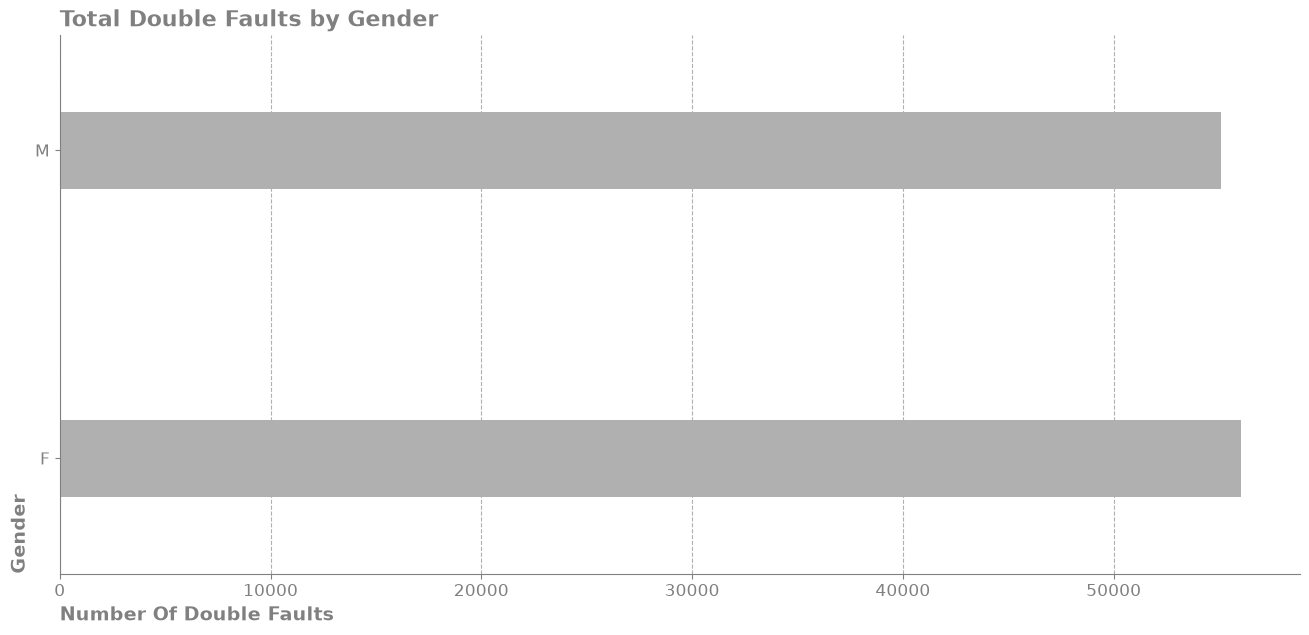

In [ ]:
fig , ax = plt.subplots(figsize=(16,7))
doublefault_genders_merged_table.plot(kind='barh', ax=ax,y='all_doublt_faults',x='gender', color='#B0B0B0', legend=False, width=0.25)

ax.spines[["right", "top"]].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.set_title('Total Double Faults by Gender', loc='left',weight='bold',color='gray',fontsize=16)
ax.set_xlabel('Number Of Double Faults',loc="left", weight="bold", color="gray", fontsize=14 )
ax.set_ylabel('Gender',loc="bottom", weight="bold", color="gray", fontsize=14 )

ax.grid(axis='x', linestyle='dashed')

#fig.savefig("8_Double Faults by Gender.png", dpi=300, bbox_inches="tight")
plt.show()

#### There is **no relationship** between Gender and number of Double Faults.

<br><br>

## 9. Which player has won the most tournaments in a single month?

In [44]:
tournament = tournament_df[['match_id','tournament_id', 'tournament_name']]
event = event_df[['match_id', 'winner_code', 'start_datetime']]
final_rounds = round_df[round_df['name']=='Final']

In [45]:
finalists_details = ( pd.merge(final_rounds, event, on='match_id')
                    .merge(tournament, on='match_id')
                    .merge(opponents, on='match_id')
                    [['match_id', 'tournament_id', 'full_name_home', 'full_name_away', 'winner_code', 'start_datetime']]
                    .drop_duplicates())

In [46]:
finalists_details["winner"] = np.where(
    finalists_details["winner_code"] == 1,
    finalists_details["full_name_home"],
    finalists_details["full_name_away"]
)
finalists_details

,match_id,tournament_id,full_name_home,full_name_away,winner_code,start_datetime,winner
0,12002073,126218,"Ostapenko, Jelena","Alexandrova, Ekaterina",1.0,1707051600,"Ostapenko, Jelena"
3,12002069,126217,"Shnaider, Diana","Zhu, Lin",1.0,1707042600,"Shnaider, Diana"
5,11998663,126174,"Jasika, Omar","Bolt, Alex",1.0,1707012000,"Jasika, Omar"
7,11999016,126192,"Rodionov, Jurij","Nakashima, Brandon",1.0,1707051600,"Rodionov, Jurij"
10,12038725,126312,"Vilicich, Bautista","Barranco Cosano, Javier",2.0,1707031800,"Barranco Cosano, Javier"
...,...,...,...,...,...,...,...
1084,12174004,127997,"Mejia, Nicolas","Soto, Matias",1.0,1711920600,"Mejia, Nicolas"
1085,12174254,128005,"Couacaud, Enzo",Vallejo Daniel,2.0,1711902600,Vallejo Daniel
1088,12174433,128011,"Jones, Francesca","Podoroska, Nadia",2.0,1711931400,"Podoroska, Nadia"
1119,12210337,128267,"Tona, Miriana","Kozyreva, Maria",2.0,1711893600,"Kozyreva, Maria"


In [47]:
finalists_details.groupby('winner')['tournament_id'].aggregate(trophies='count').reset_index()

,winner,trophies
0,"Adams, Harrison",1
1,"Agwi, Michael",1
2,"Alcala Gurri, Max",1
3,"Alcaraz, Carlos",1
4,"Alves, Carolina",1
...,...,...
199,"Zelníčková, Radka",1
200,"Zucchini, Arianna",1
201,"de Minaur, Alex",1
202,"van Wyk, Kris",1


#### As you see, among this two month **every tournament has unique champion**. Nobody achieved more trophies than the other on this two monthes.

<br><br>

## 10. Is there a correlation between a player's height and their ranking?

In [48]:
home_height = ( all_matches[['match_id','name_home','height_home','current_rank_home']]
               .rename(columns={'name_home':'name', 'height_home':'height', 'current_rank_home':'current_rank'}) )

away_height = ( all_matches[['match_id','name_away','height_away','current_rank_away']]
               .rename(columns={'name_away':'name', 'height_away':'height', 'current_rank_away':'current_rank'}) )

height_players = pd.concat([home_height, away_height])

In [49]:
fill_value = height_players['height'].dropna().mean().round(2)
height_players['height'] = height_players['height'].fillna(fill_value)
height_players.dropna()
height_players

,match_id,name,height,current_rank
0,11998445,Cazaux A.,1.83,86.0
1,11998446,Lestienne C.,1.80,99.0
2,11998447,Ćorić B.,1.88,31.0
3,11998448,Mmoh M.,1.88,122.0
4,11998449,Paire B.,1.96,110.0
...,...,...,...,...
9877,12212212,Derdoy F.,1.82,1489.0
9878,12213156,Soriano Barrera A.,1.91,465.0
9879,12213412,Taberner C.,1.83,358.0
9880,12213458,Simonsson F.,1.88,NaN


In [50]:
height_players = height_players[['height','current_rank']].corr()
height_players

,height,current_rank
height,1.000000,0.046975
current_rank,0.046975,1.000000


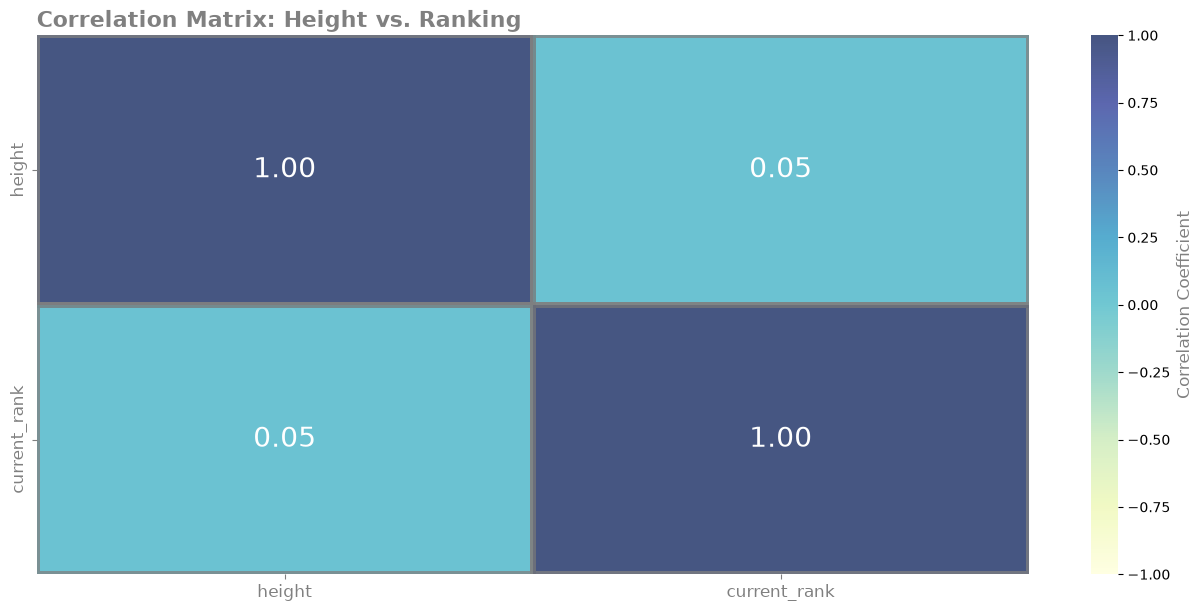

In [ ]:
fig , ax = plt.subplots(figsize=(16,7))
heatmap = sns.heatmap(data=height_players, 
                        annot=True, 
                        fmt='.2f', 
                        annot_kws={'size':20}, 
                        cmap='YlGnBu',
                        linewidths=3,
                        linecolor='gray',
                        vmin=-1, 
                        vmax=1,
                        center=0, 
                        alpha=0.75,
                        cbar=True,
                        cbar_kws={'label':'Correlation Coefficient','orientation': 'vertical'},
                        ax=ax)

cbar = heatmap.collections[0].colorbar
cbar.set_label('Correlation Coefficient', color='gray', fontsize=12)

ax.spines[["right", "top"]].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.set_title('Correlation Matrix: Height vs. Ranking', loc='left',weight='bold',color='gray',fontsize=16)
ax.set_xlabel('')
ax.set_ylabel('')

#fig.savefig("10_Correlation Matrix Height vs. Ranking.png", dpi=300, bbox_inches="tight")
plt.show()

#### **Correlation Score:** $0.05$
#### There is **almost no meaningful relationship** between a players's height and their ranking .

<br><br>

## 11. What is the average duration of matches?

In [52]:
avg_duration_per_minutes = ( time['match_duration'].sum() / time['match_id'].count() ) / 60
avg_duration_per_minutes = pd.DataFrame({'avg_duration' : [avg_duration_per_minutes]}).round(2)
avg_duration_per_minutes

,avg_duration
0,103.28


#### Every match might take about **103 minutes** to play.

<br><br>

## 12. What is the average number of games per set in men's matches compared to women's matches?

In [53]:
filtered_scores = score.filter(regex='^(?!.*tie)(match|current|period)')

In [54]:
details_period = ( set_scores.merge(filtered_scores,on='match_id',suffixes=['_valid','_invalid'])
                  .filter(regex='match|valid|period')
                  .drop(columns=['current_score_home_invalid','current_score_away_invalid']) )

In [55]:
home_cols = [c for c in details_period.columns if c.startswith('period_') and c.endswith('_home')]
away_cols = [c for c in details_period.columns if c.startswith('period_') and c.endswith('_away')]

home_all_null = details_period[home_cols].isnull().all(axis=1)
away_all_null = details_period[away_cols].isnull().all(axis=1)

details_period = details_period[~(home_all_null | away_all_null)]
details_period = details_period.dropna(subset=['current_score_home_valid', 'current_score_away_valid'], how='any')
details_period

,match_id,current_score_home_valid,current_score_away_valid,period_1_home,period_2_home,period_3_home,period_4_home,period_5_home,period_1_away,period_2_away,period_3_away,period_4_away,period_5_away
1,11998445,1.0,2.0,5.0,6.0,6.0,NaN,NaN,7.0,2.0,7.0,NaN,NaN
2,11998446,0.0,2.0,4.0,1.0,NaN,NaN,NaN,6.0,6.0,NaN,NaN,NaN
3,11998447,2.0,0.0,6.0,6.0,NaN,NaN,NaN,4.0,0.0,NaN,NaN,NaN
4,11998448,2.0,0.0,6.0,6.0,NaN,NaN,NaN,4.0,4.0,NaN,NaN,NaN
5,11998449,0.0,2.0,1.0,4.0,NaN,NaN,NaN,6.0,6.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16228,12213482,2.0,0.0,6.0,6.0,NaN,NaN,NaN,3.0,4.0,NaN,NaN,NaN
16229,12213483,2.0,0.0,6.0,6.0,NaN,NaN,NaN,2.0,4.0,NaN,NaN,NaN
16230,12213484,2.0,0.0,6.0,6.0,NaN,NaN,NaN,2.0,3.0,NaN,NaN,NaN
16231,12213486,2.0,0.0,6.0,6.0,NaN,NaN,NaN,2.0,4.0,NaN,NaN,NaN


In [56]:
matches_based_on_gender = ( matches_based_on_gender.drop('gender_away', axis='columns')
                                                    .rename(columns={'gender_home':'gender'}) )
matches_based_on_gender

,match_id,gender
0,11998445,M
1,11998446,M
2,11998447,M
3,11998448,M
4,11998449,M
...,...,...
9877,12212212,M
9878,12213156,M
9879,12213412,M
9880,12213458,M


In [57]:
periods_compared_gender = pd.merge(matches_based_on_gender, details_period, on='match_id').fillna(0)
periods_compared_gender

,match_id,gender,current_score_home_valid,current_score_away_valid,period_1_home,period_2_home,period_3_home,period_4_home,period_5_home,period_1_away,period_2_away,period_3_away,period_4_away,period_5_away
0,11998445,M,1.0,2.0,5.0,6.0,6.0,0.0,0.0,7.0,2.0,7.0,0.0,0.0
1,11998446,M,0.0,2.0,4.0,1.0,0.0,0.0,0.0,6.0,6.0,0.0,0.0,0.0
2,11998447,M,2.0,0.0,6.0,6.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0
3,11998448,M,2.0,0.0,6.0,6.0,0.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0
4,11998449,M,0.0,2.0,1.0,4.0,0.0,0.0,0.0,6.0,6.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8429,12212212,M,2.0,0.0,6.0,6.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0
8430,12213156,M,2.0,1.0,7.0,4.0,6.0,0.0,0.0,5.0,6.0,1.0,0.0,0.0
8431,12213412,M,0.0,2.0,2.0,1.0,0.0,0.0,0.0,6.0,6.0,0.0,0.0,0.0
8432,12213458,M,1.0,2.0,0.0,7.0,5.0,0.0,0.0,6.0,5.0,10.0,0.0,0.0


In [58]:
periods_compared_gender['sum_period_1'] = periods_compared_gender['period_1_home'] + periods_compared_gender['period_1_away']
periods_compared_gender['sum_period_2'] = periods_compared_gender['period_2_home'] + periods_compared_gender['period_2_away']
periods_compared_gender['sum_period_3'] = periods_compared_gender['period_3_home'] + periods_compared_gender['period_3_away']
periods_compared_gender['sum_period_4'] = periods_compared_gender['period_4_home'] + periods_compared_gender['period_4_away']
periods_compared_gender['sum_period_5'] = periods_compared_gender['period_5_home'] + periods_compared_gender['period_5_away']

In [59]:
periods_compared_gender = periods_compared_gender[['gender','sum_period_1','sum_period_2','sum_period_3','sum_period_4','sum_period_5']]

avg_periods_compared_gender = ( periods_compared_gender.groupby('gender')
                                [['sum_period_1','sum_period_2','sum_period_3','sum_period_4','sum_period_5']]
                                .aggregate('mean')
                                .round(2)
                                .rename(columns={'sum_period_1':'avg_game_set_1',
                                                'sum_period_2':'avg_game_set_2',
                                                'sum_period_3':'avg_game_set_3', 
                                                'sum_period_4':'avg_game_set_4', 
                                                'sum_period_5':'avg_game_set_5'}))
avg_periods_compared_gender

,avg_game_set_1,avg_game_set_2,avg_game_set_3,avg_game_set_4,avg_game_set_5
gender,,,,,
F,9.24,9.22,3.09,0.0,0.0
M,9.68,9.52,3.33,0.0,0.0


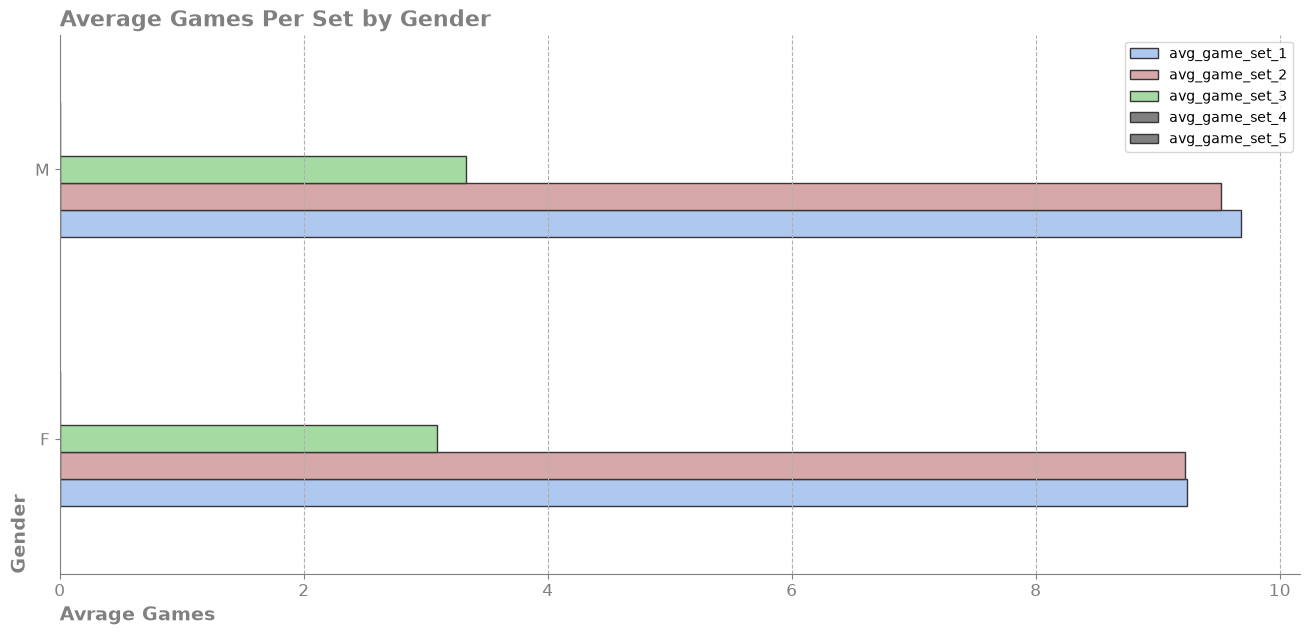

In [ ]:
fig , ax = plt.subplots(figsize=(16,7))
avg_periods_compared_gender.plot(kind='barh', ax=ax, color=["#AEC8F0","#D6A8A8","#A5DAA2",'gray','gray'],edgecolor="#383636")


ax.spines[["right", "top"]].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")


ax.set_title('Average Games Per Set by Gender', loc='left',weight='bold',color='gray',fontsize=16)
ax.set_xlabel('Avrage Games',loc="left", weight="bold", color="gray", fontsize=14 )
ax.set_ylabel('Gender',loc="bottom", weight="bold", color="gray", fontsize=14 )

ax.grid(axis='x', linestyle='dashed')

#fig.savefig("12_Average Games Per Set by Gender.png", dpi=300, bbox_inches="tight")
plt.show()

#### The average number of games in Sets 4 and 5 is `0` for both men and women. This indicates that, on average, matches in the dataset did not extend to the fourth or fifth set.

#### This result suggests that most matches were completed within the first three sets, with very few or no matches reaching the later stages of a full five-set format. As a consequence, Sets 4 and 5 do not contribute meaningfully to the overall average game pattern in this dataset.

<br><br>

## 13. What is the distribution of left-handed versus right-handed players?

In [61]:
players_which_hand_playing = all_matches[['match_id', 'name_home', 'plays_home', 'name_away', 'plays_away']].dropna()
players_which_hand_playing

,match_id,name_home,plays_home,name_away,plays_away
0,11998445,Cazaux A.,right-handed,Auger-Aliassime F.,right-handed
1,11998446,Lestienne C.,right-handed,Cobolli F.,right-handed
2,11998447,Ćorić B.,right-handed,Martínez P.,right-handed
3,11998448,Mmoh M.,right-handed,Muller A.,right-handed
4,11998449,Paire B.,right-handed,Mayot H.,right-handed
...,...,...,...,...,...
9869,12212078,Lys E.,right-handed,Dodin O.,right-handed
9870,12212080,Šrámková R.,right-handed,Jeanjean L.,right-handed
9871,12212087,Carlé M.,right-handed,Bejlek S.,left-handed
9878,12213156,Damas M.,right-handed,Soriano Barrera A.,right-handed


In [62]:
playing_hands = ( pd.concat( [players_which_hand_playing['plays_home'], players_which_hand_playing['plays_away']] )
                 .to_frame()
                 .rename(columns={0: 'playing_hand'}) )

playing_hands = ( playing_hands.groupby('playing_hand')['playing_hand']
                                .aggregate(count='count')
                                .reset_index()
                                .sort_values(by='playing_hand', ascending=False) )
playing_hands

,playing_hand,count
1,right-handed,6638
0,left-handed,930


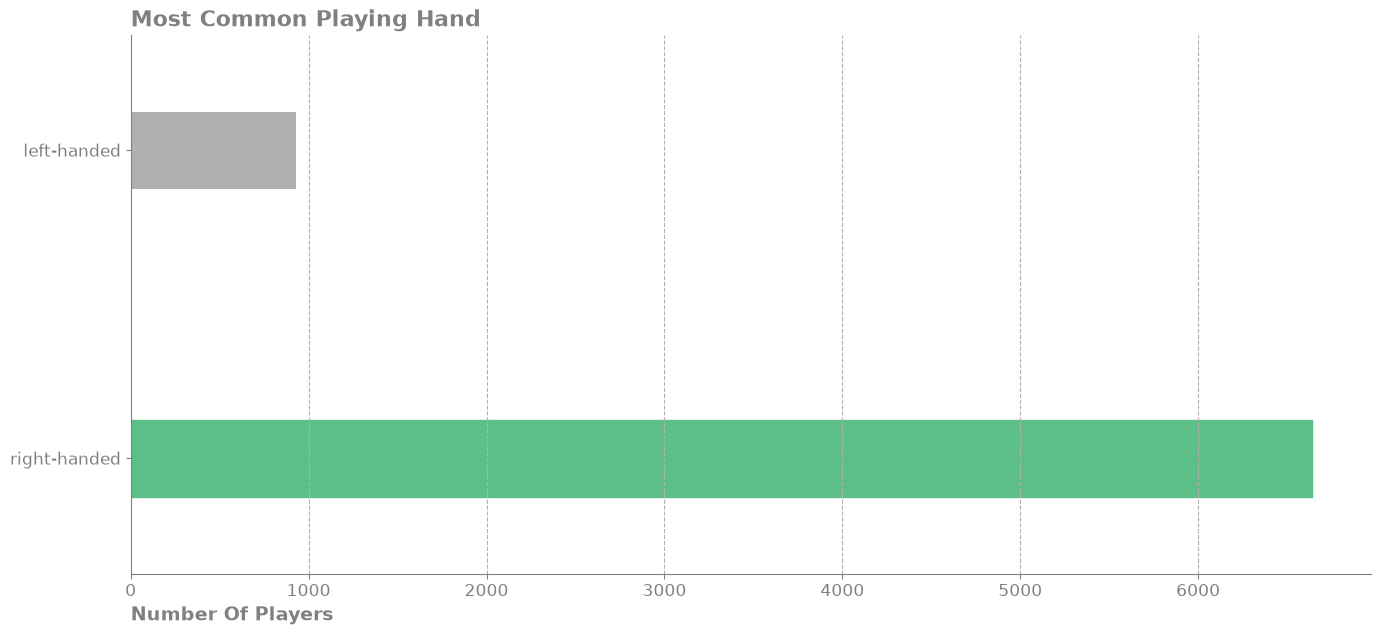

In [ ]:
fig , ax = plt.subplots(figsize=(16,7))
playing_hands.plot(kind='barh', ax=ax,y='count',x='playing_hand', color='#B0B0B0', legend=False, width=0.25)
ax.patches[0].set_color("#5CBF87")

ax.spines[["right", "top"]].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.set_title('Most Common Playing Hand', loc='left',weight='bold',color='gray',fontsize=16)
ax.set_xlabel('Number Of Players',loc="left", weight="bold", color="gray", fontsize=14 )
ax.set_ylabel('',loc="bottom", weight="bold", color="gray", fontsize=14 )

ax.grid(axis='x', linestyle='dashed')

#fig.savefig("13_Most Common Playing Hand.png", dpi=300, bbox_inches="tight")
plt.show()

<br><br>

## 14. What is the most common type of surface used in tournaments?

In [64]:
matches_and_their_grounds = tournament_df[['match_id', 'ground_type']].dropna()
ground_counts = matches_and_their_grounds['ground_type'].value_counts().to_frame().reset_index()
ground_counts

,ground_type,count
0,Hardcourt outdoor,16959
1,Red clay,11856
2,Hardcourt indoor,4741
3,Red clay indoor,512
4,Grass,509
5,Carpet indoor,276
6,Synthetic outdoor,226
7,Green clay,30


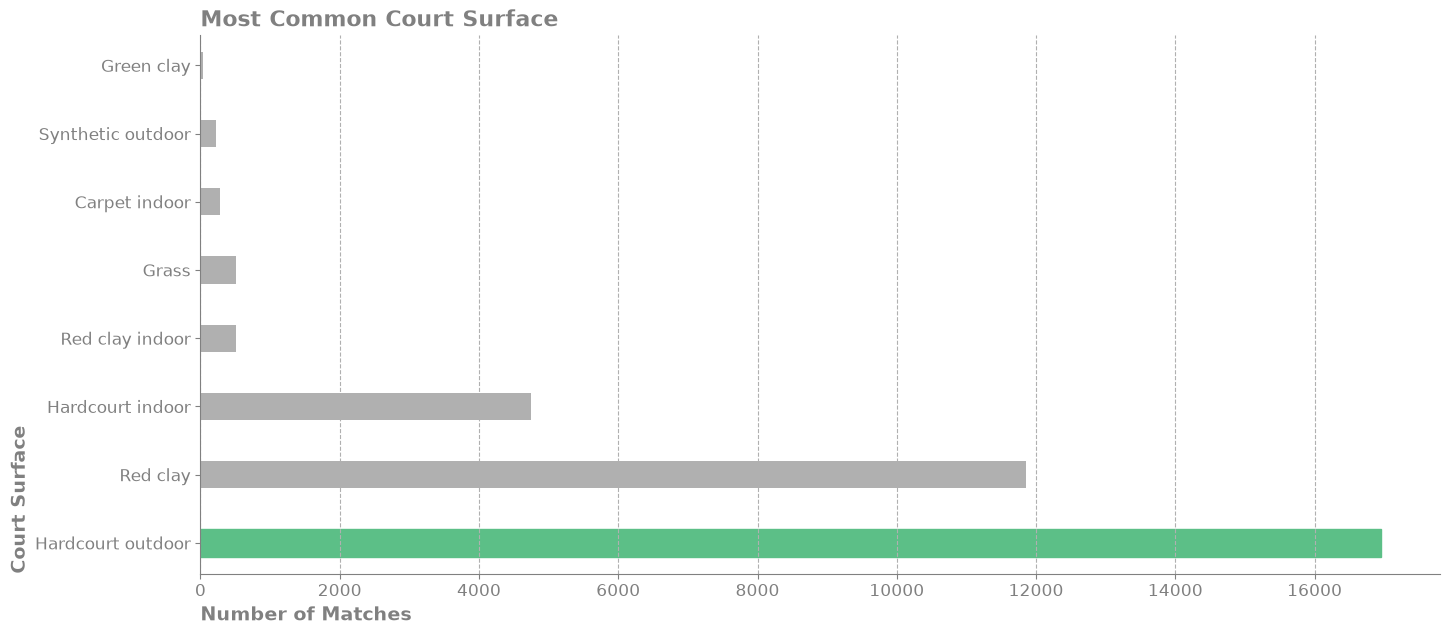

In [ ]:
fig , ax = plt.subplots(figsize=(16,7))
ground_counts.plot(kind='barh', ax=ax,y='count',x='ground_type', color='#B0B0B0', legend=False, width=0.4)
ax.patches[0].set_color("#5CBF87")

ax.spines[["right", "top"]].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.set_title('Most Common Court Surface', loc='left',weight='bold',color='gray',fontsize=16)
ax.set_xlabel('Number of Matches',loc="left", weight="bold", color="gray", fontsize=14 )
ax.set_ylabel('Court Surface',loc="bottom", weight="bold", color="gray", fontsize=14 )

ax.grid(axis='x', linestyle='dashed')

#fig.savefig("14_Most Common Court Surface.png", dpi=300, bbox_inches="tight")
plt.show()

<br><br>

## 15. How many distinct countries are represented in the dataset?

In [66]:
home_players_based_on_countries = ( all_matches[['player_id_home', 'country_home']].dropna()
                                   .rename(columns={'player_id_home': 'player_id', 'country_home': 'country'}) ) 

away_players_based_on_countries = ( all_matches[['player_id_away', 'country_away']].dropna()
                                   .rename(columns={'player_id_away': 'player_id', 'country_away': 'country'}) )

In [67]:
all_players_countries = pd.concat([home_players_based_on_countries, away_players_based_on_countries]).drop_duplicates()
all_players_countries

,player_id,country
0,287803,France
1,62790,France
2,64580,Croatia
3,131442,USA
4,22218,France
...,...,...
9643,227875,USA
9702,384985,Bosnia & Herzegovina
9717,468519,United Kingdom
9737,509586,Brazil


In [68]:
count_players_by_county = ( all_players_countries.groupby('country')['country']
                        .aggregate(count='count')
                        .reset_index()
                        .sort_values(by='count',ascending=False) )
count_players_by_county

,country,count
88,USA,219
41,Italy,202
29,France,200
74,Russia,133
44,Japan,120
...,...,...
55,Malta,1
61,New Caledonia,1
75,Senegal,1
66,Pakistan,1


In [69]:
number_countries = pd.DataFrame({'count': [count_players_by_county['country'].count()]})
number_countries

,count
0,96


#### The number of distinct countries that their players participated in the tournaments is **96**.

<br><br>

## 16. Which player has the highest winning percentage against top 10 ranked opponents?

In [70]:
top_10 = wins.head(10)
top_10

,winner_name,wins,winner_id
195,"Popko, Dmitry",31,50901.0
1282,"Chidekh, Clement",24,231620.0
1926,"Faria, Jaime",22,341818.0
1265,"Jianu, Filip Cristian",21,230049.0
1339,"Ovcharenko, Oleksandr",21,238867.0
1024,"Gengel, Marek",21,202572.0


In [71]:
opponents = all_matches[['match_id','player_id_home','name_home','player_id_away','name_away']]
winner_code = event_df[['match_id','winner_code']]
opponents_details = pd.merge(opponents, winner_code, on='match_id').dropna()
opponents_details.head()

,match_id,player_id_home,name_home,player_id_away,name_away,winner_code
0,11998445,287803,Cazaux A.,192013,Auger-Aliassime F.,2.0
1,11998446,62790,Lestienne C.,273680,Cobolli F.,2.0
2,11998447,64580,Ćorić B.,77223,Martínez P.,1.0
3,11998448,131442,Mmoh M.,88992,Muller A.,1.0
4,11998449,22218,Paire B.,248846,Mayot H.,2.0


In [72]:
condition =  ( opponents_details['player_id_home'].isin(top_10['winner_id']) ) | ( opponents_details['player_id_away'].isin(top_10['winner_id']) )
all_top_10_matches = opponents_details[condition]

In [73]:
all_top_10_matches['winner_id'] = ( np.where(all_top_10_matches['winner_code']==1,
                                            all_top_10_matches['player_id_home'], 
                                            all_top_10_matches['player_id_away']) )

all_top_10_matches['winner_name'] = ( np.where(all_top_10_matches['winner_code']==1, 
                                               all_top_10_matches['name_home'], 
                                               all_top_10_matches['name_away']) )

winners_on_top10_matches = all_top_10_matches[['winner_id','winner_name']]
winners_on_top10_matches

,winner_id,winner_name
147,238867,Ovcharenko O.
178,202572,Gengel M.
235,202572,Gengel M.
247,118040,Klok D.
343,202572,Gengel M.
...,...,...
9415,202572,Gengel M.
9519,202572,Gengel M.
9580,111857,Ursu V.
9604,341818,Faria J.


In [74]:
winners_vs_top10 = winners_on_top10_matches[~(winners_on_top10_matches['winner_id'].isin(top_10['winner_id']))]
number_wins_vs_top10_by_players = ( winners_vs_top10.groupby('winner_name')['winner_name']
                                  .aggregate(count='count')
                                  .sort_values(by='count',ascending=False)
                                  .reset_index() )
number_wins_vs_top10_by_players['percentage'] = (number_wins_vs_top10_by_players['count'] / number_wins_vs_top10_by_players['count'].sum() * 100).round(2)
number_wins_vs_top10_by_players

,winner_name,count,percentage
0,van Wyk K.,2,12.50
1,Araujo P.,1,6.25
2,Baez S.,1,6.25
3,Boyer T.,1,6.25
4,Buse I.,1,6.25
5,Cerundolo F.,1,6.25
6,Dodig M.,1,6.25
7,Ficovich J.,1,6.25
8,Heller P.,1,6.25
9,Klok D.,1,6.25


In [75]:
number_wins_vs_top10_by_players[number_wins_vs_top10_by_players['percentage'] == number_wins_vs_top10_by_players['percentage'].max()]

,winner_name,count,percentage
0,van Wyk K.,2,12.5


#### **K. Van Wyk** has the highest rate of winning against top 10 players with **%12.5** with number of two wins .

<br><br>

## 17. What is the average number of breaks of serve per match?

In [76]:
breaks = power_df[['match_id', 'break_occurred']].drop_duplicates()
breaks

,match_id,break_occurred
0,11998445,False
4,11998445,True
33,11998446,False
41,11998446,True
50,11998447,False
...,...,...
469627,12213484,True
469643,12213486,False
469644,12213486,True
469661,12213803,False


In [77]:
avg_breaks_per_match = ( breaks['break_occurred'].sum() /  breaks['break_occurred'].count() ).round(2)
avg_breaks_per_match = pd.DataFrame({'avg_breaks_per_games': [avg_breaks_per_match]})
avg_breaks_per_match

,avg_breaks_per_games
0,0.5


#### The average number of breaks of serve per match is **0.5** .


<br><br>

## 18. Who Is The Richest Player In The Dataset?

In [78]:
home_players_finance = ( all_matches[['full_name_home','total_prize_home']]
                        .rename(columns={'full_name_home':'full_name', 'total_prize_home':'total_prize'}) )
away_players_finance = ( all_matches[['full_name_away','total_prize_away']]
                        .rename(columns={'full_name_away':'full_name', 'total_prize_away':'total_prize'}) )

In [79]:
all_players_finance = pd.concat([home_players_finance, away_players_finance]).drop_duplicates(subset='full_name')
fill_value = all_players_finance.dropna().mean(numeric_only=True).round(2)
all_players_finance = all_players_finance.fillna(fill_value).sort_values(by='total_prize', ascending=False).head(5)
all_players_finance

,full_name,total_prize
6106,"Djokovic, Novak",151332515.0
5845,"Nadal, Rafael",112216420.0
3179,"Murray, Andy",53623813.0
5872,"Williams, Venus",35496164.0
7833,"Halep, Simona",33502864.0


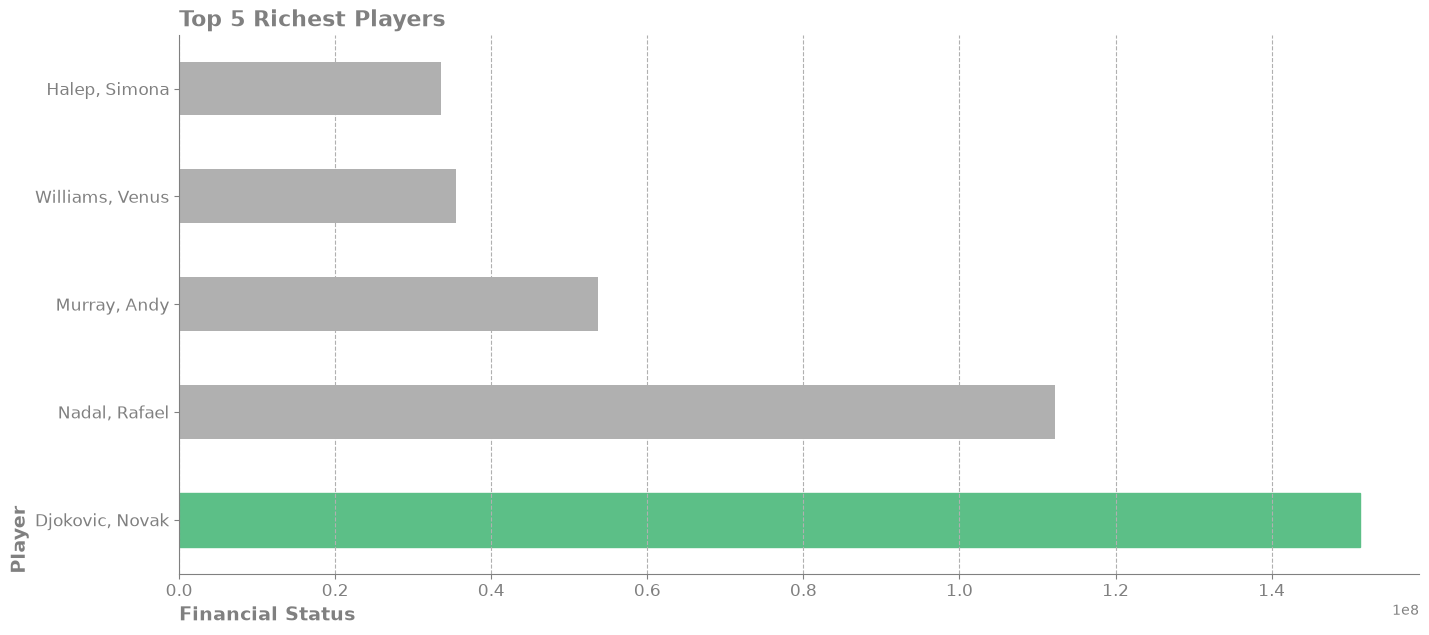

In [ ]:
fig , ax = plt.subplots(figsize=(16,7))
all_players_finance.plot(kind='barh', ax=ax, x='full_name', y='total_prize', color='#B0B0B0', legend=False)
ax.patches[0].set_color("#5CBF87")

ax.spines[["right", "top"]].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.set_title('Top 5 Richest Players', loc='left',weight='bold',color='gray',fontsize=16)
ax.set_xlabel('Financial Status',loc="left", weight="bold", color="gray", fontsize=14 )
ax.set_ylabel('Player',loc="bottom", weight="bold", color="gray", fontsize=14 )

ax.grid(axis='x', linestyle='dashed')

#fig.savefig("18_The Richest Players.png", dpi=300, bbox_inches="tight")
plt.show()

<br><br>

## 19. Which City Hosted The Most? 

In [81]:
venue = venue_df[['match_id','city']].drop_duplicates().dropna()
venue = venue.groupby('city')['match_id'].aggregate(number_hosted='count').reset_index().sort_values(by='number_hosted',ascending=False).head(5)
venue

,city,number_hosted
6,Antalya,1542
105,Monastir,1350
156,Sharm El Sheikh,1337
61,Heraklion,547
58,Hammamet,428


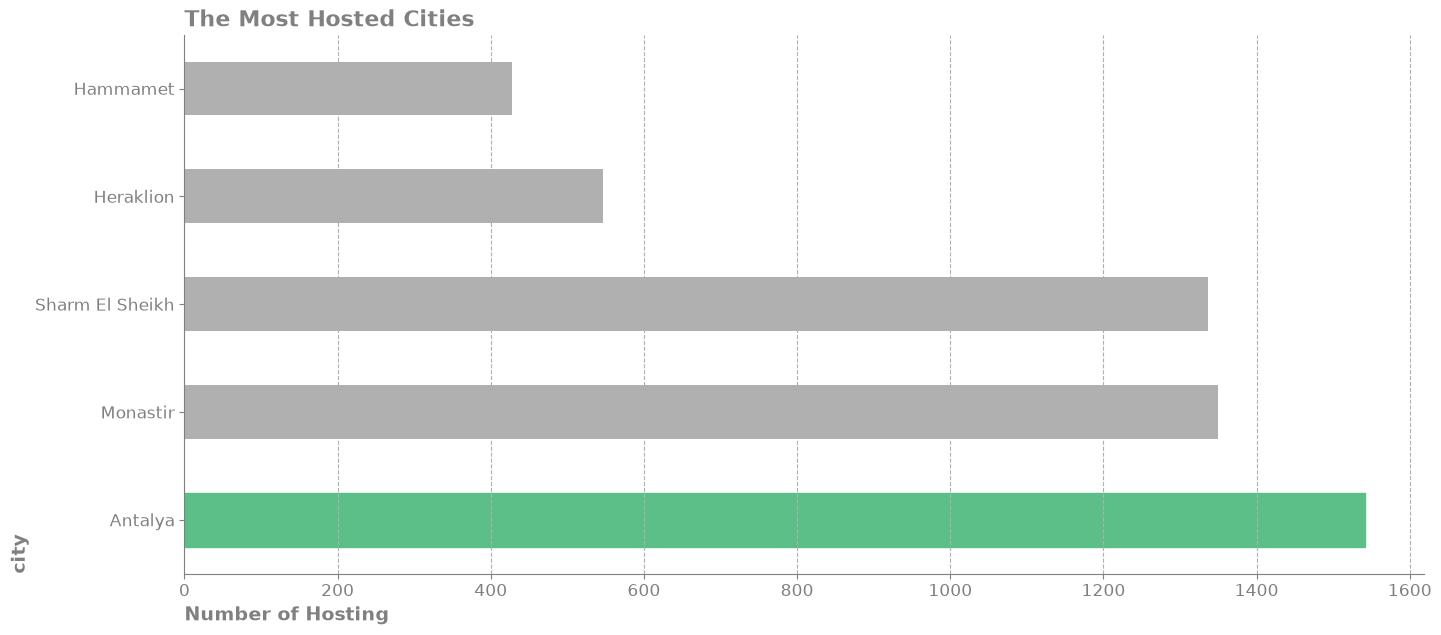

In [ ]:
fig , ax = plt.subplots(figsize=(16,7))
venue.plot(kind='barh', ax=ax, x='city', y='number_hosted', color='#B0B0B0', legend=False)
ax.patches[0].set_color("#5CBF87")

ax.spines[["right", "top"]].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.set_title('The Most Hosted Cities', loc='left',weight='bold',color='gray',fontsize=16)
ax.set_xlabel('Number of Hosting',loc="left", weight="bold", color="gray", fontsize=14 )
ax.set_ylabel('city',loc="bottom", weight="bold", color="gray", fontsize=14 )

ax.grid(axis='x', linestyle='dashed')

#fig.savefig("19_The Most Hosted Cities.png", dpi=300, bbox_inches="tight")
plt.show()

<br><br>

## 20.Who Is The King of Red Clay?

In [83]:
red_clay_matche_ids = tournament_df[tournament_df['ground_type']=='Red clay']['match_id']
red_clay_matches = all_matches[all_matches['match_id'].isin(red_clay_matche_ids)]
red_clay_matches = red_clay_matches[['match_id','full_name_home','full_name_away']]

In [84]:
red_clay_event = event[event['match_id'].isin(red_clay_matche_ids)].dropna()

In [85]:
red_clay_details = pd.merge(red_clay_matches,red_clay_event, on='match_id')
red_clay_details

,match_id,full_name_home,full_name_away,winner_code,start_datetime
0,11999209,"Alves, Mateus","Ugo Carabelli, Camilo",2.0,1706729400
1,11999210,"Stodder, Timo","Feldbausch, Kilian",2.0,1706745900
2,11999211,"Casanova, Hernan","Mager, Gianluca",2.0,1706797500
3,11999212,"Pucinelli de Almeida, Matheus","Lavagno, Edoardo",1.0,1706792400
4,11999213,"Coria, Federico","Torres, Juan Bautista",1.0,1706799000
...,...,...,...,...,...
2727,12212205,"Pérez, Brandon","Ratti, Lucio",2.0,1711974600
2728,12212207,"Corthey, Lautaro Agustin","Ribero, Franco",2.0,1711974600
2729,12212212,"Falabella, Lautaro Agustin","Derdoy, Felipe",1.0,1711974600
2730,12213156,"Damas, Miguel","Soriano Barrera, Adria",1.0,1711972800


In [86]:
red_clay_winners = np.where(
    red_clay_details['winner_code'] == 1,
    red_clay_details['full_name_home'],
    red_clay_details['full_name_away']
)

red_clay_winners = pd.DataFrame(red_clay_winners, columns=['red_clay_winners'])
red_clay_winners = ( red_clay_winners.groupby('red_clay_winners')['red_clay_winners']
                    .aggregate(count='count')
                    .reset_index()
                    .sort_values(by='count',ascending=False).head() )
red_clay_winners

,red_clay_winners,count
186,"Dellien Velasco, Murkel Alejandro",19
604,"Popko, Dmitry",19
354,"Jianu, Filip Cristian",18
154,"Clarke, Jay",18
764,"Ugo Carabelli, Camilo",16


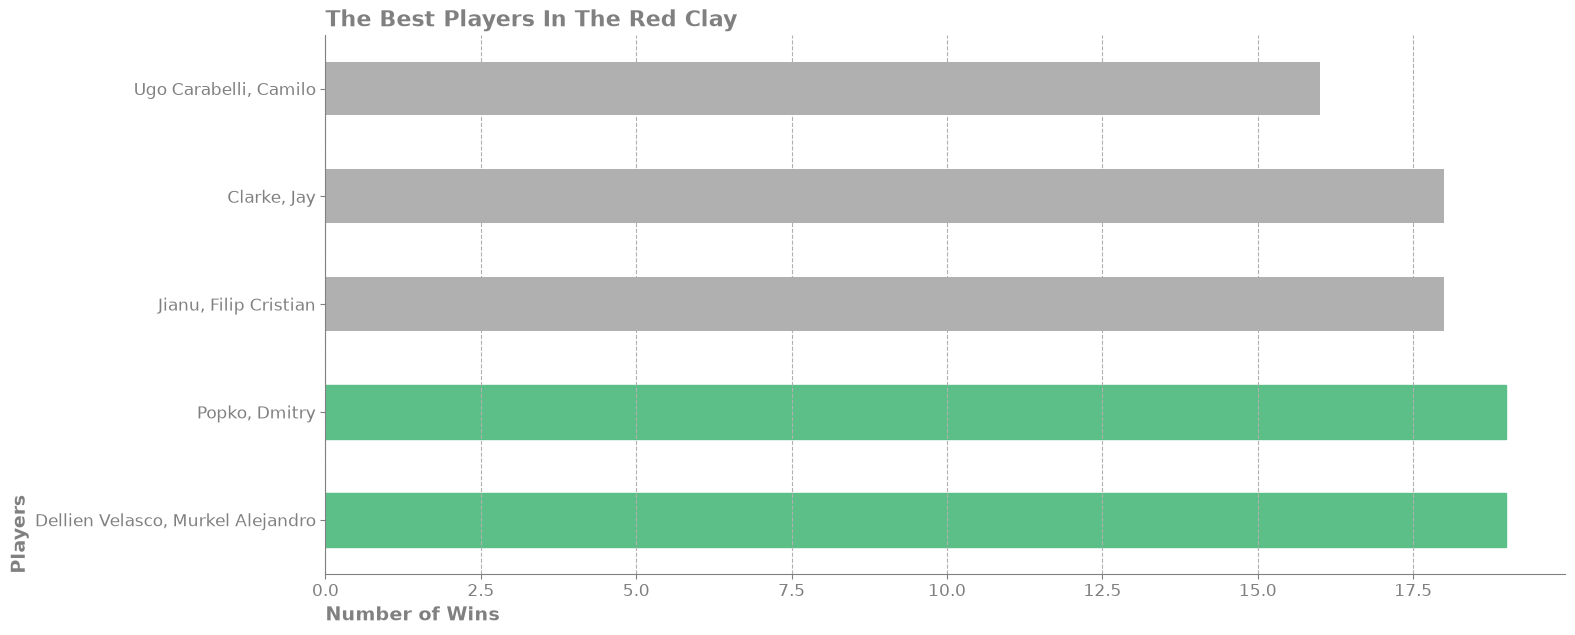

In [ ]:
fig , ax = plt.subplots(figsize=(16,7))
red_clay_winners.plot(kind='barh', ax=ax, x='red_clay_winners', y='count', color='#B0B0B0', legend=False)
ax.patches[0].set_color("#5CBF87")
ax.patches[1].set_color("#5CBF87")

ax.spines[["right", "top"]].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.set_title('The Best Players In The Red Clay', loc='left',weight='bold',color='gray',fontsize=16)
ax.set_xlabel('Number of Wins',loc="left", weight="bold", color="gray", fontsize=14 )
ax.set_ylabel('Players',loc="bottom", weight="bold", color="gray", fontsize=14 )

ax.grid(axis='x', linestyle='dashed')

#fig.savefig("20_The Best Players In The Red Clay.png", dpi=300, bbox_inches="tight")
plt.show()

<br><br>

## 21. What percentage of all players turned pro between 2010 and 2020?

In [88]:
home = all_matches[['full_name_home','turned_pro_home']].rename(columns={'full_name_home':'full_name','turned_pro_home':'turned_pro'})
away = all_matches[['full_name_away','turned_pro_away']].rename(columns={'full_name_away':'full_name','turned_pro_away':'turned_pro'})
players_turned_pro = pd.concat([home,away]).dropna().drop_duplicates()

In [89]:
each_year_count_players_turned_pro = players_turned_pro.groupby('turned_pro')['full_name'].aggregate(number_players='count').reset_index()

In [90]:
criteria_2010_to_2020 = each_year_count_players_turned_pro[each_year_count_players_turned_pro['turned_pro']>=2010]

In [91]:
finale = (( criteria_2010_to_2020['number_players'].sum() / each_year_count_players_turned_pro['number_players'].sum() ) * 100).round(2)
finale = pd.DataFrame({'percentage': [finale]})
finale

,percentage
0,69.45


#### About **%69.45** of players turned pro between years 2010 up to 2020.

<br><br>

## 22. What Percentage of Players Are Male And Female?

In [92]:
home = all_matches[['full_name_home','gender_home']].rename(columns={'full_name_home':'full_name','gender_home':'gender'})
away = all_matches[['full_name_away','gender_away']].rename(columns={'full_name_away':'full_name','gender_away':'gender'})
players_genders = pd.concat([home,away]).dropna().drop_duplicates()
players_genders

,full_name,gender
0,"Cazaux, Arthur",M
1,"Lestienne, Constant",M
2,"Ćorić, Borna",M
3,"Mmoh, Michael",M
4,"Paire, Benoit",M
...,...,...
9641,"Sebov, Katherine",F
9643,"Mandlik, Elizabeth",F
9717,"Robertson, Charlie",M
9737,"Almeida, Joaquim",M


In [93]:
players_genders_counts= players_genders.groupby('gender')['full_name'].aggregate(count='count').reset_index()
players_genders_counts

,gender,count
0,F,1197
1,M,1371


In [94]:
players_genders_counts['pecentage'] = (( players_genders_counts['count'] / players_genders_counts['count'].sum() ) * 100 ).round(2)
players_genders_counts

,gender,count,pecentage
0,F,1197,46.61
1,M,1371,53.39


#### Distribution male players are bigger than female players.

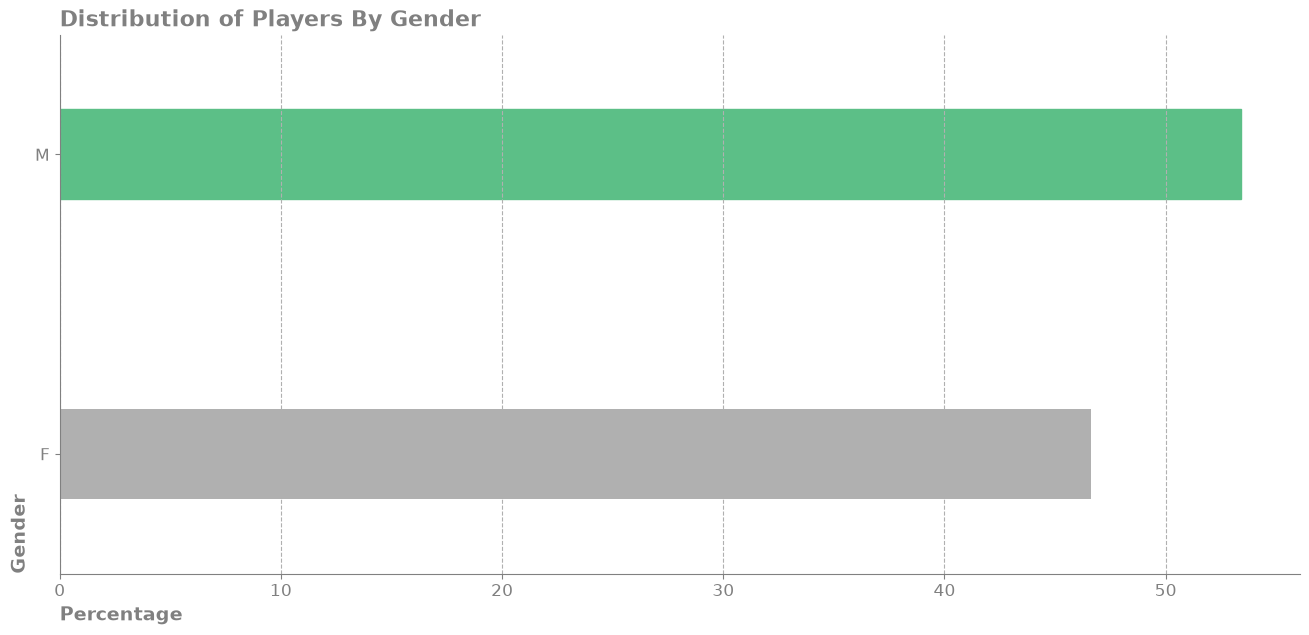

In [ ]:
fig , ax = plt.subplots(figsize=(16,7))
players_genders_counts.plot(kind='barh', ax=ax, x='gender', y='pecentage', color='#B0B0B0', legend=False, width=0.3)
ax.patches[1].set_color("#5CBF87")

ax.spines[["right", "top"]].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.set_title('Distribution of Players By Gender', loc='left',weight='bold',color='gray',fontsize=16)
ax.set_xlabel('Percentage',loc="left", weight="bold", color="gray", fontsize=14 )
ax.set_ylabel('Gender',loc="bottom", weight="bold", color="gray", fontsize=14 )

ax.grid(axis='x', linestyle='dashed')

#fig.savefig("22_Distribution of Players By Gender.png", dpi=300, bbox_inches="tight")
plt.show()

<br><br>

## 23. What do the players’ BMIs indicate?

In [96]:
home = ( all_matches[['full_name_home','player_id_home','weight_home','height_home']]
        .rename(columns={'full_name_home':'full_name', 'player_id_home':'player_id', 'weight_home':'weight', 'height_home':'height'}) )
away = ( all_matches[['full_name_away','player_id_away','weight_away','height_away']]
        .rename(columns={'full_name_away':'full_name', 'player_id_away':'player_id', 'weight_away':'weight', 'height_away':'height'}) )
player_physical_details = pd.concat([home,away]).drop_duplicates()

In [97]:
fill_weight = player_physical_details['weight'].dropna().mean()
fill_height = player_physical_details['height'].dropna().mean()
player_physical_details['weight'] = player_physical_details['weight'].fillna(fill_weight).round(2)
player_physical_details['height'] = player_physical_details['height'].fillna(fill_height).round(2)
player_physical_details

,full_name,player_id,weight,height
0,"Cazaux, Arthur",287803,75.23,1.83
1,"Lestienne, Constant",62790,72.00,1.80
2,"Ćorić, Borna",64580,85.00,1.88
3,"Mmoh, Michael",131442,90.00,1.88
4,"Paire, Benoit",22218,80.00,1.96
...,...,...,...,...
9643,"Mandlik, Elizabeth",227875,75.23,1.70
9702,"Tucakovic, Suana",384985,75.23,1.82
9717,"Robertson, Charlie",468519,75.23,1.82
9737,"Almeida, Joaquim",509586,75.23,1.82


In [98]:
player_physical_details['BMI'] = ( player_physical_details['weight'] / ( player_physical_details['height'] ** 2 ) ).round(2)
player_physical_details

,full_name,player_id,weight,height,BMI
0,"Cazaux, Arthur",287803,75.23,1.83,22.46
1,"Lestienne, Constant",62790,72.00,1.80,22.22
2,"Ćorić, Borna",64580,85.00,1.88,24.05
3,"Mmoh, Michael",131442,90.00,1.88,25.46
4,"Paire, Benoit",22218,80.00,1.96,20.82
...,...,...,...,...,...
9643,"Mandlik, Elizabeth",227875,75.23,1.70,26.03
9702,"Tucakovic, Suana",384985,75.23,1.82,22.71
9717,"Robertson, Charlie",468519,75.23,1.82,22.71
9737,"Almeida, Joaquim",509586,75.23,1.82,22.71


In [99]:
conditionlist = [player_physical_details['BMI'] <= 18.5,
                (player_physical_details['BMI'] > 18.5) & (player_physical_details['BMI'] < 25),
                (player_physical_details['BMI'] >= 25) & (player_physical_details['BMI'] <= 30),
                player_physical_details['BMI'] > 30]
choicelist = ['Under Weight', 'Normal Weight', 'Over Weight', 'Obesity']

player_physical_details['BMI_status'] = np.select(conditionlist,choicelist,default='Unknown')
BMI_status = player_physical_details['BMI_status'].value_counts().to_frame().reset_index()
BMI_status

,BMI_status,count
0,Normal Weight,2442
1,Over Weight,153
2,Under Weight,15
3,Obesity,1


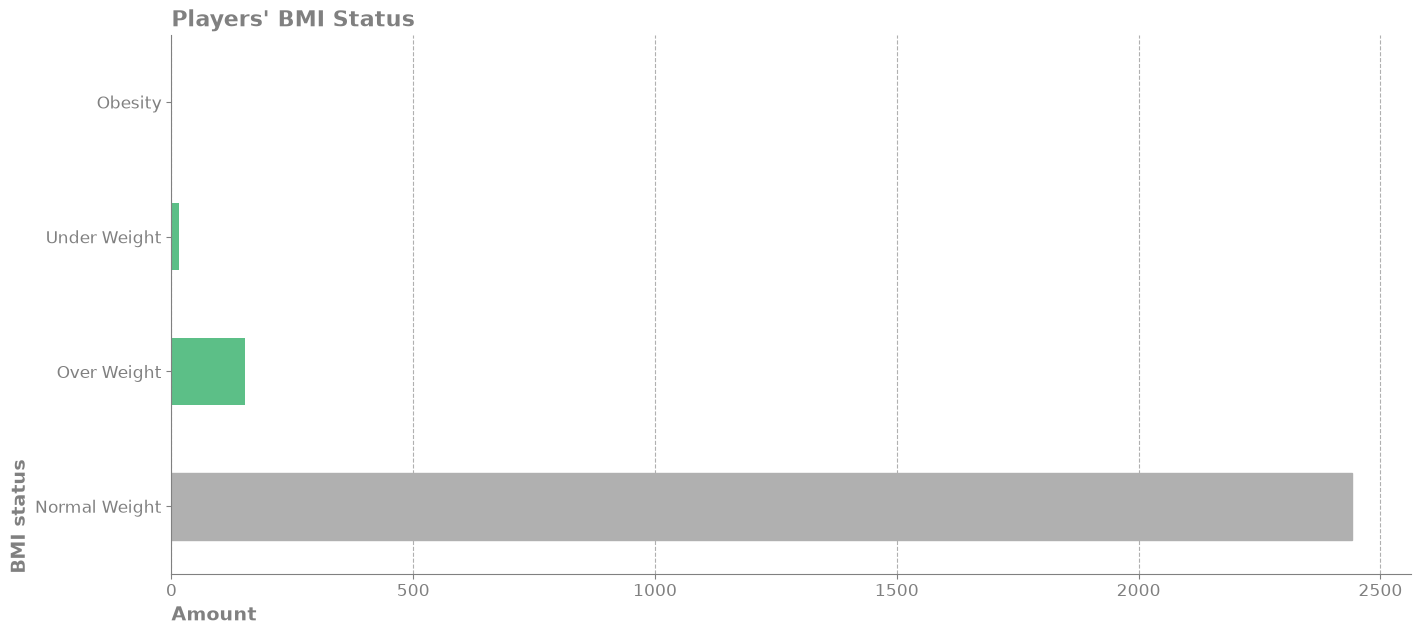

In [ ]:
fig , ax = plt.subplots(figsize=(16,7))
BMI_status.plot(kind='barh', ax=ax, x='BMI_status', y='count', color='#5CBF87', legend=False)
ax.patches[0].set_color("#B0B0B0")

ax.spines[["right", "top"]].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.set_title("Players' BMI Status", loc='left',weight='bold',color='gray',fontsize=16)
ax.set_xlabel('Amount',loc="left", weight="bold", color="gray", fontsize=14 )
ax.set_ylabel('BMI status',loc="bottom", weight="bold", color="gray", fontsize=14 )

ax.grid(axis='x', linestyle='dashed')

#fig.savefig("23_BMI status.png", dpi=300, bbox_inches="tight")
plt.show()

#### The Number Of 'Obesity' Player is **1**. Not Been Displayed So Well In The Plot.